# Sup Figure 1 | Strand-Bias and Insert-Level Fitness

## Configuration

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
import numpy as np


In [20]:
# --- data directory (populate yourself -- see README's Data section) ---
DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --- paths ---
GENE_DATA_PATH = DATA_DIR / "gene_fitness_lmm_results.parquet"

# --- analysis parameters ---
CONDITION = "LB_4_salt"

df_raw = pd.read_parquet(GENE_DATA_PATH)
print(f"{len(df_raw):,} rows loaded")
salt_genes = df_raw[df_raw["condition"] == CONDITION].copy()
print(f"{len(salt_genes):,} rows filtered")


100,786 rows loaded
50,393 rows filtered


In [21]:
pd.set_option('display.max_columns', None)
salt_gene_hits = salt_genes[salt_genes["gene_call"] == "Hit"]
salt_gene_hits.head()


,pioneer_genome,species_name,gene_id,locus_tag,gene_bioname,gene_biotype,gene_chrom,gene_strand,gene_start,gene_end,cds_length,protein_id,bayes_estimate,bayes_z_score,bayes_gene_sigma,bayes_q_value,cluster_id,cluster_size,max_r,pip,L,interpretation,condition,lmer_estimate,lmer_standard_error,lmer_shapiro_stat,lmer_shapiro_p,lmer_insert_var,lmer_z_value,lmer_p_value,lmer_q_value,n_inserts,n_sense_inserts,n_antisense_inserts,VIF,gene_call,unk_bucket_0,unk_bucket_1,unk_bucket_2,unk_bucket_3,bayes_island_id,orthogroup,is_single_copy,seed_ortholog,evalue,score,eggNOG_OGs,COG_category,Description,Preferred_name,GOs,EC,KEGG_ko,KEGG_Pathway,KEGG_Module,best_e_coli_k12_match,pident_to_e_coli_k12,PFAMs,PFAM_descriptions,gc_content,CAI_rel_to_Ecoli,EFF_CODON_N,RARE_CODON_N
51172,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0740,b0740,tolB,protein_coding,NC_000913.3,+,777740,779032,1292.0,NP_415268.1,0.775098,6.761715,0.119908,2.124099e-08,2302.0,17.0,0.719874,9.999974e-01,1.0,collinear hit (positive),LB_4_salt,1.703007,0.330180,0.910845,0.005234,0.394090,5.157819,2.993856e-07,6.641603e-05,13.0,0.0,13.0,3.224448,Hit,False,False,False,False,group_4,OG0002024,False,155864.EDL933_0820,2.686000e-286,879.0,"COG0823@1|root,COG0823@2|Bacteria,1MV09@1224|P...",U,Involved in the TonB-independent uptake of,tolB,"GO:0003674,GO:0005215,GO:0005488,GO:0005515,GO...",NaN,ko:K03641,NaN,NaN,NaN,NaN,"[PF04052, PF07676, PF07676, PF07676, PF07676]","[TolB amino-terminal domain, WD40-like Beta Pr...",53.13,0.4641,43.20,2.0
51183,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0751,b0751,pnuC,protein_coding,NC_000913.3,+,783166,783885,719.0,NP_415272.1,-0.300113,-3.856292,0.077360,1.421204e-02,2302.0,17.0,0.761718,2.804574e-07,1.0,neighbor causal (negative),LB_4_salt,-0.607540,0.158295,0.948092,0.000038,0.390216,-3.838023,1.313989e-04,1.327241e-02,50.0,31.0,19.0,2.373622,Hit,False,False,False,False,group_6,OG0003050,False,198214.SF0553,1.588000e-148,470.0,"COG3201@1|root,COG3201@2|Bacteria,1MXN4@1224|P...",H,nicotinamide mononucleotide transporter,pnuC,"GO:0003674,GO:0005215,GO:0005337,GO:0005575,GO...",NaN,ko:K03811,NaN,NaN,NaN,NaN,[PF04973],[Nicotinamide mononucleotide transporter],48.19,0.3304,53.40,5.0
51255,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0819,b0819,ldtB,protein_coding,NC_000913.3,-,854824,855744,920.0,NP_415340.1,-0.411536,-4.552271,0.093175,1.625629e-03,995.0,6.0,0.603703,9.982100e-01,1.0,collinear hit (negative),LB_4_salt,-0.711530,0.154183,0.966275,0.028110,0.367349,-4.614827,4.429319e-06,7.618749e-04,31.0,15.0,16.0,1.486245,Hit,False,False,False,False,group_8,OG0000554,False,316407.4062386,8.781000e-202,628.0,"COG1376@1|root,COG1376@2|Bacteria,1MVYT@1224|P...",M,"Responsible, at least in part, for anchoring o...",ybiS,"GO:0000270,GO:0003674,GO:0003824,GO:0004180,GO...",NaN,"ko:K16291,ko:K19234,ko:K19235,ko:K19236","ko01503,map01503",NaN,NaN,NaN,"[PF03734, PF17969]","[L,D-transpeptidase catalytic domain, L,D-tran...",52.99,0.5153,40.14,0.0
51295,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0858,b0858,ybjO,protein_coding,NC_000913.3,+,897989,898477,488.0,NP_415379.1,2.880579,26.079830,0.115464,9.565750e-134,1816.0,4.0,0.617578,1.000000e+00,1.0,collinear hit (positive),LB_4_salt,6.946661,0.288877,0.964289,0.159023,0.569289,24.047148,9.101011e-102,4.320614e-98,17.0,7.0,10.0,2.421843,Hit,False,False,False,False,group_12,OG0005409,False,155864.EDL933_0987,3.915000e-96,315.0,"2E0RG@1|root,32W9M@2|Bacteria,1RGQB@1224|Prote...",S,Protein of unknown function (DUF2593),ybjO,"GO:0005575,GO:0005623,GO:0005886,GO:0016020,GO...",NaN,NaN,NaN,NaN,NaN,NaN,[PF10767],"[Inner membrane protein YbjO, dehydrogenase-like]",52.15,0.3379,51.38,3.0
51297,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0860,b0860,artJ,protein_coding,NC_000913.3,-,899844,900575,731.0,NP_415381.1,-0.495077,-3.908254,0.129091,1.545980e-02,1816.0,4.0,0.55

In [22]:
salt_direction_stats = pd.read_parquet(DATA_DIR / "strand_direction_stats.parquet")


In [23]:
salt_direction_stats.head()

,locus_tag,lmer_estimate,lmer_standard_error,lmer_z_value,lmer_p_value,lmer_rev_estimate,lmer_rev_standard_error,lmer_rev_z_value,lmer_rev_p_value,lmer_antisense_estimate,lmer_antisense_se,lmer_antisense_z,lmer_antisense_p,lmer_n_sense_inserts,lmer_n_antisense_inserts,lmer_shapiro_stat,lmer_shapiro_p,lmer_insert_var,lmer_q_value,lmer_rev_q_value,lmer_antisense_q_value
0,C2H97_RS02530,0.986481,0.702349,1.404546,0.160361,-0.814000,0.813044,-1.001176,0.316922,0.172481,0.410257,0.420421,0.674178,1,19,0.958324,0.054261,0.386640,0.616038,0.770574,0.935446
1,C2H97_RS02535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,13,NaN,NaN,NaN,NaN,NaN,NaN
2,PYW03_RS16675,-0.541718,0.345042,-1.570007,0.116750,0.158346,0.328208,0.482457,0.629590,-0.383372,0.261109,-1.468245,0.142038,7,10,0.978976,0.523112,0.383199,0.560301,0.910716,0.635996
3,PYW03_RS16680,0.453370,0.291091,1.557488,0.119680,-0.060831,0.289668,-0.210003,0.833709,0.392539,0.261028,1.503818,0.132628,10,10,0.985682,0.724935,0.378623,0.565104,0.971113,0.622144
4,GOBS_RS03355,0.870326,0.490075,1.775905,0.076027,-0.648555,0.380897,-1.702703,0.088899,0.221771,0.331810,0.668368,0.503899,4,23,0.915009,0.000129,0.365437,0.478658,0.509632,0.883508


In [24]:
salt_direction_stats.sort_values(by='lmer_rev_p_value', ascending=True, inplace=True)
salt_direction_stats.rename(columns={"lmer_estimate": "lmer_sense_estimate"}, inplace=True)
salt_direction_stats["fract_sense_inserts"] = salt_direction_stats["lmer_n_sense_inserts"] / (salt_direction_stats["lmer_n_sense_inserts"] + salt_direction_stats["lmer_n_antisense_inserts"])

In [25]:
salt_hits_extended = salt_gene_hits.merge(salt_direction_stats[["locus_tag", "lmer_sense_estimate", "lmer_antisense_estimate", "lmer_rev_estimate", "lmer_rev_p_value", "fract_sense_inserts"]], 
                                       on = "locus_tag", how = "left")

salt_hits_extended

,pioneer_genome,species_name,gene_id,locus_tag,gene_bioname,gene_biotype,gene_chrom,gene_strand,gene_start,gene_end,cds_length,protein_id,bayes_estimate,bayes_z_score,bayes_gene_sigma,bayes_q_value,cluster_id,cluster_size,max_r,pip,L,interpretation,condition,lmer_estimate,lmer_standard_error,lmer_shapiro_stat,lmer_shapiro_p,lmer_insert_var,lmer_z_value,lmer_p_value,lmer_q_value,n_inserts,n_sense_inserts,n_antisense_inserts,VIF,gene_call,unk_bucket_0,unk_bucket_1,unk_bucket_2,unk_bucket_3,bayes_island_id,orthogroup,is_single_copy,seed_ortholog,evalue,score,eggNOG_OGs,COG_category,Description,Preferred_name,GOs,EC,KEGG_ko,KEGG_Pathway,KEGG_Module,best_e_coli_k12_match,pident_to_e_coli_k12,PFAMs,PFAM_descriptions,gc_content,CAI_rel_to_Ecoli,EFF_CODON_N,RARE_CODON_N,lmer_sense_estimate,lmer_antisense_estimate,lmer_rev_estimate,lmer_rev_p_value,fract_sense_inserts
0,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0740,b0740,tolB,protein_coding,NC_000913.3,+,777740,779032,1292.0,NP_415268.1,0.775098,6.761715,0.119908,2.124099e-08,2302.0,17.0,0.719874,9.999974e-01,1.0,collinear hit (positive),LB_4_salt,1.703007,0.330180,0.910845,0.005234,0.394090,5.157819,2.993856e-07,6.641603e-05,13.0,0.0,13.0,3.224448,Hit,False,False,False,False,group_4,OG0002024,False,155864.EDL933_0820,2.686000e-286,879.0,"COG0823@1|root,COG0823@2|Bacteria,1MV09@1224|P...",U,Involved in the TonB-independent uptake of,tolB,"GO:0003674,GO:0005215,GO:0005488,GO:0005515,GO...",NaN,ko:K03641,NaN,NaN,NaN,NaN,"[PF04052, PF07676, PF07676, PF07676, PF07676]","[TolB amino-terminal domain, WD40-like Beta Pr...",53.13,0.4641,43.20,2.0,NaN,NaN,NaN,NaN,0.000000
1,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0751,b0751,pnuC,protein_coding,NC_000913.3,+,783166,783885,719.0,NP_415272.1,-0.300113,-3.856292,0.077360,1.421204e-02,2302.0,17.0,0.761718,2.804574e-07,1.0,neighbor causal (negative),LB_4_salt,-0.607540,0.158295,0.948092,0.000038,0.390216,-3.838023,1.313989e-04,1.327241e-02,50.0,31.0,19.0,2.373622,Hit,False,False,False,False,group_6,OG0003050,False,198214.SF0553,1.588000e-148,470.0,"COG3201@1|root,COG3201@2|Bacteria,1MXN4@1224|P...",H,nicotinamide mononucleotide transporter,pnuC,"GO:0003674,GO:0005215,GO:0005337,GO:0005575,GO...",NaN,ko:K03811,NaN,NaN,NaN,NaN,[PF04973],[Nicotinamide mononucleotide transporter],48.19,0.3304,53.40,5.0,-0.905995,-0.280335,0.625659,1.931663e-03,0.620000
2,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0819,b0819,ldtB,protein_coding,NC_000913.3,-,854824,855744,920.0,NP_415340.1,-0.411536,-4.552271,0.093175,1.625629e-03,995.0,6.0,0.603703,9.982100e-01,1.0,collinear hit (negative),LB_4_salt,-0.711530,0.154183,0.966275,0.028110,0.367349,-4.614827,4.429319e-06,7.618749e-04,31.0,15.0,16.0,1.486245,Hit,False,False,False,False,group_8,OG0000554,False,316407.4062386,8.781000e-202,628.0,"COG1376@1|root,COG1376@2|Bacteria,1MVYT@1224|P...",M,"Responsible, at least in part, for anchoring o...",ybiS,"GO:0000270,GO:0003674,GO:0003824,GO:0004180,GO...",NaN,"ko:K16291,ko:K19234,ko:K19235,ko:K19236","ko01503,map01503",NaN,NaN,NaN,"[PF03734, PF17969]","[L,D-transpeptidase catalytic domain, L,D-tran...",52.99,0.5153,40.14,0.0,-0.600944,-0.826105,-0.225161,3.436081e-01,0.483871
3,Escherichia_coli_K-12_substr._MG1655_GCF_00000...,Escherichia coli,gene-b0858,b0858,ybjO,protein_coding,NC_000913.3,+,897989,898477,488.0,NP_415379.1,2.880579,26.079830,0.115464,9.565750e-134,1816.0,4.0,0.617578,1.000000e+00,1.0,collinear hit (positive),LB_4_salt,6.946661,0.288877,0.964289,0.159023,0.569289,24.047148,9.101011e-102,4.320614e-98,17.0,7.0,10.0,2.421843,Hit,False,False,False,False,group_12,OG0005409,False,155864.EDL933_0987,3.915000e-96,315.0,"2E0RG@1|root,32W9M@2|Bacteria,1RGQB@1224|Prote...",S,Protein of unknown function (DUF2593),ybjO,"GO:0005575,GO:0005623,GO:0005886,GO:0016020,GO...",NaN,NaN,NaN,NaN,NaN,NaN,[PF10767],"[Inner membrane protein YbjO, dehydrogenase-like]",52.15,0.3379,51.38,3.0,5.

In [26]:
salt_hits_extended_filt = salt_hits_extended[(salt_hits_extended["n_sense_inserts"] >= 2) & 
                                            (salt_hits_extended["n_antisense_inserts"] >= 2)]

salt_hits_extended_filt.sort_values(by='lmer_rev_p_value', ascending=False, inplace=True)
salt_hits_extended_filt["p_value_fdr"] = multipletests(salt_hits_extended_filt["lmer_rev_p_value"], method="fdr_bh")[1]
salt_hits_extended_filt["neg_log10_p_value_fdr"] = -np.log10(salt_hits_extended_filt["p_value_fdr"])
salt_hits_extended_filt["sig_p_value_fdr"] = salt_hits_extended_filt["p_value_fdr"] < 0.05
salt_hits_extended_filt["sig_p_value_fdr"].value_counts()

sig_p_value_fdr
False    175
True     115
Name: count, dtype: int64

In [27]:
salt_hits_extended_filt.sort_values(by='lmer_rev_p_value', ascending=True).head(n=15)

,pioneer_genome,species_name,gene_id,locus_tag,gene_bioname,gene_biotype,gene_chrom,gene_strand,gene_start,gene_end,cds_length,protein_id,bayes_estimate,bayes_z_score,bayes_gene_sigma,bayes_q_value,cluster_id,cluster_size,max_r,pip,L,interpretation,condition,lmer_estimate,lmer_standard_error,lmer_shapiro_stat,lmer_shapiro_p,lmer_insert_var,lmer_z_value,lmer_p_value,lmer_q_value,n_inserts,n_sense_inserts,n_antisense_inserts,VIF,gene_call,unk_bucket_0,unk_bucket_1,unk_bucket_2,unk_bucket_3,bayes_island_id,orthogroup,is_single_copy,seed_ortholog,evalue,score,eggNOG_OGs,COG_category,Description,Preferred_name,GOs,EC,KEGG_ko,KEGG_Pathway,KEGG_Module,best_e_coli_k12_match,pident_to_e_coli_k12,PFAMs,PFAM_descriptions,gc_content,CAI_rel_to_Ecoli,EFF_CODON_N,RARE_CODON_N,lmer_sense_estimate,lmer_antisense_estimate,lmer_rev_estimate,lmer_rev_p_value,fract_sense_inserts,p_value_fdr,neg_log10_p_value_fdr,sig_p_value_fdr
289,Pseudomonas_putida_KT2440_GCF_045571375.1,Pseudomonas putida,gene-PYW03_RS06940,PYW03_RS06940,mraY,protein_coding,NZ_CP118872.1,+,1512747,1513829,1082.0,WP_003251852.1,2.024594,17.002960,0.124460,6.174383e-56,195.0,30.0,0.526077,1.000000e+00,1.0,clean hit (positive),LB_4_salt,5.272432,0.295247,0.941051,0.049817,0.610706,17.857683,4.460210e-62,1.323400e-58,13.0,8.0,5.0,1.660154,Hit,False,False,False,False,group_662,OG0000800,True,351746.Pput_4390,1.814000e-228,708.0,"COG0472@1|root,COG0472@2|Bacteria,1MUTK@1224|P...",M,First step of the lipid cycle reactions in the...,mraY,"GO:0000270,GO:0003674,GO:0003824,GO:0005575,GO...",2.7.8.13,ko:K01000,"ko00550,ko01100,ko01502,map00550,map01100,map0...",NaN,NP_414629.1,63.90,"[PF00953, PF10555]","[Glycosyl transferase family 4, Phospho-N-acet...",61.31,0.4588,35.56,5.0,8.051673,0.339719,-7.711954,2.524398e-74,0.615385,7.320753e-72,71.135444,True
292,Pseudomonas_putida_KT2440_GCF_045571375.1,Pseudomonas putida,gene-PYW03_RS12620,PYW03_RS12620,PYW03_RS12620,protein_coding,NZ_CP118872.1,+,2737546,2738241,695.0,WP_010953354.1,1.536114,20.057047,0.082799,9.863368e-73,299.0,10.0,0.841271,1.255662e-13,1.0,neighbor causal (positive),LB_4_salt,1.390560,0.347341,0.979272,0.065048,0.859983,4.003444,6.654050e-05,7.858069e-03,41.0,19.0,22.0,3.705951,Hit,False,False,False,False,group_664,singleton:WP_010953354.1,False,160488.PP_2399,1.805000e-150,475.0,"COG3219@1|root,COG3219@2|Bacteria,1R8C9@1224|P...",S,Putative DNA-binding domain,NaN,NaN,NaN,ko:K09929,NaN,NaN,NaN,NaN,"[PF09836, PF22106]","[Putative DNA-binding domain, NGO1945 C-termin...",62.93,0.2966,48.17,3.0,-0.854234,4.783927,5.638161,7.537899e-65,0.463415,1.092995e-62,61.961382,True
293,Pseudomonas_putida_KT2440_GCF_045571375.1,Pseudomonas putida,gene-PYW03_RS12625,PYW03_RS12625,PYW03_RS12625,protein_coding,NZ_CP118872.1,-,2738276,2738764,488.0,WP_010953355.1,1.780742,21.491043,0.083089,4.235264e-99,299.0,10.0,0.841271,1.000000e+00,1.0,collinear hit (positive),LB_4_salt,4.322000,0.358222,0.974674,0.028008,0.862033,12.065133,1.364437e-31,1.750684e-28,40.0,23.0,17.0,3.915785,Hit,False,False,False,False,group_664,OG0000531,False,160488.PP_2400,6.243000e-101,329.0,"COG2259@1|root,COG2259@2|Bacteria,1RDRZ@1224|P...",S,DoxX family,NaN,NaN,NaN,ko:K15977,NaN,NaN,NaN,NaN,[PF07681],[DoxX],61.35,0.3579,42.78,4.0,6.048215,0.970666,-5.077550,7.238237e-49,0.575000,6.996963e-47,46.155090,True
111,Halomonas_elongata_DSM_2581_GCF_000196875.2,Halomonas elongata,gene-HELO_RS13580,HELO_RS13580,rpoD,protein_coding,NC_014532.2,-,2911840,2913687,1847.0,WP_013333227.1,1.429696,18.051601,0.081017,2.408500e-66,1468.0,54.0,0.560348,1.000000e+00,1.0,clean hit (positive),LB_4_salt,2.056927,0.150268,0.986692,0.185035,0.619204,13.688411,1.125739e-39,1.979383e-36,49.0,18.0,31.0,1.435991,Hit,False,False,False,False,group_267,OG0000158,False,768066.HELO_3471,0.000000e+00,1167.0,"COG0568@1|root,COG0568@2|Bacteria,1MVNJ@1224|P...",K,Sigma factors are initiation factors that prom...,rpoD,NaN,NaN,ko:K03086,NaN,NaN,NP_417539.1,67.00,"[PF00140, PF03979, PF04539, PF04542, PF0

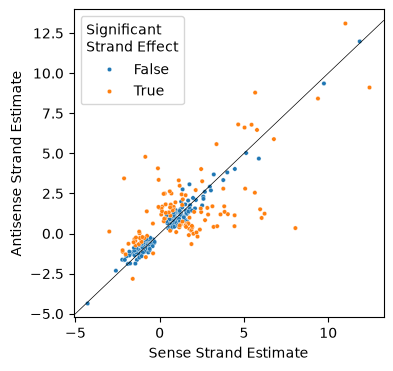

In [35]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(salt_hits_extended_filt, x="lmer_sense_estimate", y="lmer_antisense_estimate", hue = "sig_p_value_fdr", s=10, ax=ax)
plt.axline((0,0), slope = 1, color="black", linewidth=0.5)
plt.xlabel("Sense Strand Estimate")
plt.ylabel("Antisense Strand Estimate")
plt.legend(title = "Significant\nStrand Effect", loc = "upper left")

fig.savefig(RESULTS_DIR / "figureS1a_sense_antisense_scatter.pdf", bbox_inches="tight")

plt.show()


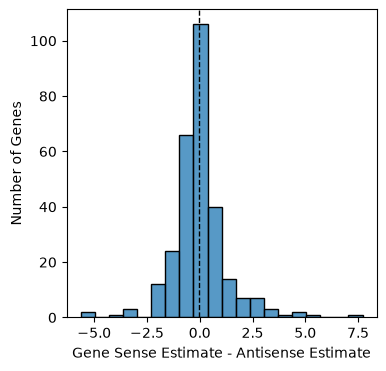

-0.04965966388395787


In [ ]:
### Supplementary 1B
fig, ax = plt.subplots(figsize=(4, 4))

salt_hits_extended_filt["lmer_fwd_estimate"] = salt_hits_extended_filt["lmer_sense_estimate"] - salt_hits_extended_filt["lmer_antisense_estimate"]
sns.histplot(salt_hits_extended_filt[~salt_hits_extended_filt["lmer_fwd_estimate"].isna()], x="lmer_fwd_estimate",
             bins=20, ax=ax)

median_effect_size = salt_hits_extended_filt["lmer_fwd_estimate"].median()

plt.ylabel("Number of Genes")
plt.xlabel("Gene Sense Estimate - Antisense Estimate")
plt.axvline(median_effect_size, color="black", linewidth=1, linestyle="--")

fig.savefig(RESULTS_DIR / "figureS1b_hist_sense_antisense_estimate_diff.pdf", bbox_inches="tight")

plt.show()

print(median_effect_size)

### Insert level plots Supplementary 1C

In [30]:
INSERT_DATA_PATH = DATA_DIR / "selection_insert_data.parquet"
inserts = pd.read_parquet(INSERT_DATA_PATH)
print(f"{len(inserts):,} rows loaded")


6,298,488 rows loaded


In [31]:
# --- Step 1: mean empty-insert fitness per replicate per environment ---
empty_bc_fitness = (
    inserts[inserts["insert_type"] == "empty_insert"]
    .groupby(["environment", "replicate"])
    .agg(
        mean_empty_bc_fitness=("fitness", "mean"),
        n_empty_bcs=("bc_sequence", "nunique"),
    )
    .reset_index()
)

# --- Step 2: center each insert against its replicate empty mean,
#             then average across replicates per barcode ---
inserts_ext = inserts.merge(empty_bc_fitness, on=["environment", "replicate"], how="left")
inserts_ext["fitness_centered"] = inserts_ext["fitness"] - inserts_ext["mean_empty_bc_fitness"]

bc_fitness_means = (
    inserts_ext[inserts_ext["insert_type"] != "unknown"]
    .groupby(["environment", "insert_type", "bc_sequence"])
    .agg(
        mean_centered_fitness=("fitness_centered", "mean"),
        std_fitness=("fitness_centered", "std"),
    )
    .reset_index()
)

# --- Step 3: re-correct against the empty-insert barcode distribution per environment ---
empty_stats = (
    bc_fitness_means[bc_fitness_means["insert_type"] == "empty_insert"]
    .groupby("environment")
    .agg(
        mean_empty_bc_fitness=("mean_centered_fitness", "mean"),
        std_empty_bc_fitness=("mean_centered_fitness", "std"),
    )
    .reset_index()
)
bc_fitness_means = bc_fitness_means.merge(empty_stats, on="environment", how="left")
bc_fitness_means["mean_fitness_corrected"] = (
    bc_fitness_means["mean_centered_fitness"] - bc_fitness_means["mean_empty_bc_fitness"]
)
bc_fitness_means["z_score"] = (
    (bc_fitness_means["mean_centered_fitness"] - bc_fitness_means["mean_empty_bc_fitness"])
    / bc_fitness_means["std_empty_bc_fitness"]
)

print(bc_fitness_means.groupby(["environment", "insert_type"]).size())

# Build one row per barcode carrying positional columns + mean_fitness_corrected.
# The raw inserts table has one row per barcode per replicate; groupby.first()
# collapses replicates so each barcode appears exactly once.
corrected = bc_fitness_means[
    bc_fitness_means["environment"] == CONDITION
][["bc_sequence", "mean_fitness_corrected"]]

annotated = (
    inserts[
        (inserts["environment"] == CONDITION)
    ]
    .merge(corrected, on="bc_sequence", how="inner")
    .groupby("bc_sequence")
    .first()
    .reset_index()
)

print(f"{len(annotated):,} unique {CONDITION} barcodes with corrected fitness")

environment  insert_type 
LB           aligned         545368
             empty_insert      4776
LB_4_salt    aligned         472449
             empty_insert      3417
dtype: int64
475,866 unique LB_4_salt barcodes with corrected fitness


In [33]:
annotated_sense_long = annotated[["bc_sequence", "mean_fitness_corrected", "sense_gene_ids"]].explode("sense_gene_ids").dropna(subset=["sense_gene_ids"]).rename(columns={"sense_gene_ids": "gene_ids"})
annotated_sense_long["direction"] = "sense"
annotated_antisense_long = annotated[["bc_sequence", "mean_fitness_corrected", "antisense_gene_ids"]].explode("antisense_gene_ids").dropna(subset=["antisense_gene_ids"]).rename(columns={"antisense_gene_ids": "gene_ids"})
annotated_antisense_long["direction"] = "antisense"
annotated_long = pd.concat([annotated_sense_long, annotated_antisense_long])
annotated_long

,bc_sequence,mean_fitness_corrected,gene_ids,direction
0,AAAAAAAAACAAAACAAAAGCAGAGGTACATGTGGTGTCTTCAC,0.005286,gene-HELO_RS13220,sense
0,AAAAAAAAACAAAACAAAAGCAGAGGTACATGTGGTGTCTTCAC,0.005286,gene-HELO_RS13230,sense
0,AAAAAAAAACAAAACAAAAGCAGAGGTACATGTGGTGTCTTCAC,0.005286,gene-HELO_RS13225,sense
4,AAAAAAAACAAAAGAAATGCAGATATTCTTTTCCTCTCTTTTG,0.229628,gene-b4269,sense
5,AAAAAAAACAAAAGCAAAGCAGAACTACCAGTCGGTTCGTTTC,-1.040973,gene-E6A55_RS00055,sense
...,...,...,...,...
475859,TTTTTGTTTAGATTTCCTTAGCAGAAGGAGAGGTCATTACATGAG,0.422459,gene-HELO_RS02610,antisense
475861,TTTTTGTTTTGACTAGAAATCCAGACAATGTGTACTGTTCTCTTC,-0.227877,gene-BBI08_RS10425,antisense
475861,TTTTTGTTTTGACTAGAAATCCAGACAATGTGTACTGTTCTCTTC,-0.227877,gene-BBI08_RS10430,antisense
475863,TTTTTTCATCTCACTTTGTCATGCGATCTTAAG,-0.339617,gene-SP68_RS00570,antisense


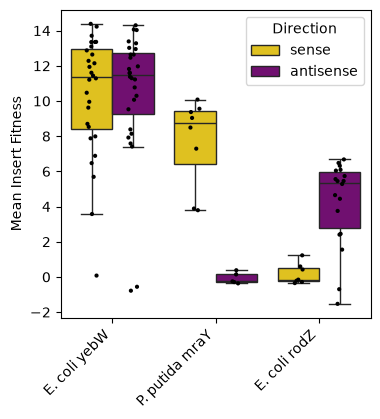

In [34]:
genes_of_interest = [ "gene-b1837", "gene-PYW03_RS06940", "gene-b2516",]
annotated_long_filt = annotated_long[annotated_long["gene_ids"].isin(genes_of_interest)]

fig, ax = plt.subplots(figsize=(4, 4))

### Use two color pallete of gold and purple
sns.boxplot(annotated_long_filt, y="mean_fitness_corrected", x="gene_ids", hue = "direction", palette = ["#FFD700", "#800080"], dodge=True, fliersize=0,
            order = ["gene-b1837", "gene-PYW03_RS06940", "gene-b2516"])
sns.stripplot(annotated_long_filt, y="mean_fitness_corrected", x="gene_ids", s=3, hue = "direction", palette = ["black", "black"], dodge=True, legend=False,
              order = ["gene-b1837", "gene-PYW03_RS06940", "gene-b2516"])

### Manually change x tick labels
plt.xticks([0, 1, 2], ["E. coli yebW", "P. putida mraY", "E. coli rodZ"], ha="right", rotation=45)
plt.xlabel("")
plt.ylabel("Mean Insert Fitness")
plt.legend(title = "Direction", loc = "upper right")

fig.savefig(RESULTS_DIR / "figureS1c_insert_level_boxplot.pdf", bbox_inches="tight")
plt.show()